本节结束后您将能够回答的问题
- 为什么集群有用？
- 集群的成本是多少？
- 如何将多处理解决方案转换为群集解决方案？
- IPython集群是如何工作的？
- 如何使用Dask和Swifter并行化Pandas？
- NSQ如何帮助制造健壮的生产系统？

集群通常被认为是一个计算机的集合，它们协同工作来解决一个共同的任务。从外部看，它可以看作是一个更大的单一系统。

在20世纪90年代，在局域网上使用商品PC集群进行集群处理（称为Beowulf集群）的概念变得流行起来。谷歌后来通过在自己的数据中心使用商品业化PC集群，特别是运行MapReduce任务，推动了这一做法。在规模的另一端，500强项目每年排名最强大的计算机系统；这些机器通常采用集群设计，速度最快的机器都使用Linux。

Amazon Web Services（AWS）通常用于云计算中的工程生产集群和为机器学习等短期任务构建按需集群。有了AWS，你可以以每小时1美元到15美元的价格租到10个CPU和768GB内存的大小机器。多个GPU可以租用额外的费用。如果您想在计算量大或RAM量大的任务上探索AWS或其他临时集群提供商，请参阅“使用IPython并行支持研究”和ElastiCluster包。

不同的计算任务需要集群中不同的配置、大小和功能。我们将在本节中定义一些常见的场景。

在移动到群集解决方案之前，请确保已执行以下操作：
- 分析您的系统以便了解瓶颈
- 利用了诸如Numba和Cython之类的编译器解决方案
- 在一台机器（可能是一台具有多核的大型机器）多核上利用Joblib或多处理开发
- 利用较少内存的技术

把你的系统放在一台机器上会让你的生活更轻松（即使“一台机器”是一台有很多RAM和CPU的非常结实的计算机）。如果您确实需要大量CPU或并行处理磁盘中的数据的能力，或者需要高弹性和快速响应等生产需求，请迁移到集群。大多数研究场景不需要弹性或可伸缩性，并且仅限于少数人，因此最简单的解决方案往往是最明智的。

呆在一台大型机器上的一个好处是，像Dask这样的工具可以快速并行化panda或普通Python代码，而不会造成网络复杂性。Dask还可以控制一组机器来并行处理Pandas、NumPy和纯Python问题。通过在Dask上搭载，Swifter自动并行一些多核单机案例。我们将在本节后面介绍Dask和Swifter。

# 集群的好处

集群最明显的好处是，如果需要处理更多的数据或更快地得到答案，您可以轻松地扩展计算需求，只需添加更多的计算机（或节点）。

通过添加机器，还可以提高可靠性。每台机器的部件都有一定的故障可能性，但如果设计良好，多个部件的故障不会停止集群的运行。

集群还用于创建动态扩展的系统。一个常见的用例是将一组处理web请求或相关数据（例如，调整用户照片大小、转码视频或转码语音）的服务器聚集起来，并随着一天中某些时间的需求增加而激活更多的服务器。

动态缩放是处理非均匀使用模式的一种非常经济有效的方法，只要机器激活时间足够快，能够处理需求变化的速度。

集群的一个更微妙的好处是集群可以在地理上分离，但仍然可以集中控制。如果一个地理区域发生中断（例如，由于洪水或电力损失），那么另一个集群可以继续工作，可能需要添加更多的处理单元来处理需求。集群还允许您运行异构软件环境（例如，不同版本的操作系统和处理软件），这可能会提高整个系统的健壮性。不过，请注意，这绝对是一个专家级的主题！

# 集群的缺点

转移到集群解决方案需要改变思路。这是从串行代码到并行代码所需的思想变化的演变，正如我们在前面课程中介绍的，你不得不考虑当你有多台机器时会发生什么？你的机器之间有延迟，你需要知道你的其他机器是否在工作，你需要让所有的机器运行相同版本的软件。系统管理可能是您最大的挑战。

此外，您通常必须认真考虑正在实现的算法，以及一旦您有了所有这些可能需要保持同步的附加运动部件之后会发生什么。这种额外的计划可能会烧脑；这很可能会分散您对核心任务的注意力，一旦系统变得足够大，您可能需要为您的团队添加一名专门的工程师。

在设计集群解决方案时，您需要记住每台计算机的配置可能不同（每台计算机将具有不同的负载和不同的本地数据）。如何将所有正确的数据传送到处理作业的机器上？移动作业和数据所涉及的延迟是否构成问题？你的工作需要互相传达部分结果吗？如果一个进程失败，或者一台机器死机，或者一些硬件在多个作业运行时自动擦除，会发生什么情况？如果你不考虑这些问题，就可能导致失败。

你也应该考虑到失败是可以接受的。例如，在运行基于内容的web服务时，如果有时某个作业失败（例如，图片的大小调整不够快），并且用户需要重新加载页面，则可能不需要99.999%的可靠性，这是每个人都已经习惯的。它可能不是您想要给用户的解决方案，但是接受一点点失败通常会降低您的工程和管理成本，这是值得的。另一方面，如果一个高频交易系统出现故障，糟糕的股票市场交易的成本可能是相当大的！

维护固定的基础设施可能会变得昂贵。机器相对便宜，但他们有一个可怕的习惯出错自动软件升级可能出现故障，网卡故障，磁盘有写错误，电源可以给尖峰的电力中断数据，宇宙射线可以翻转一点内存模块。你拥有的电脑越多，处理这些问题所浪费的时间就越多。你迟早会想请来一个能处理这些问题的系统工程师，所以在预算中再增加50万元。使用基于云的集群可以缓解很多这些问题（成本更高，但您不必处理硬件维护），一些云提供商还为廉价但临时的计算资源提供现货市场。

随着时间的推移，集群的一个潜在问题是，如果一切都关闭了，可能没有人记录过如何安全地重新启动集群。如果你没有一个文档化的重启计划，你应该假设你必须在最坏的时候写一个。在这一点上，您还将了解系统的每个部分需要多长时间才能达到速度集群的每个部分可能需要几分钟才能启动并开始处理作业，因此，如果有10个部分连续运行，那么整个系统可能需要一个小时才能从冷态运行。结果是你可能有一个小时的积压数据。那么，您是否有必要的能力及时处理这些积压工作？

懈怠的行为可能会导致代价高昂的错误，而复杂和难以预期的行为可能会导致意外和代价高昂的结果。让我们看看两个引人注目的集群故障，看看我们可以从中吸取什么教训。

## 糟糕的集群升级策略导致华尔街损失4.62亿美元

2012年，高频交易公司骑士资本（Knight Capital）在一个集群的软件升级过程中引入了一个bug，损失了4.62亿美元。该软件订购的股票数量超过了客户的要求。

在交易软件中，旧的标志被重新用于新的功能。升级被推广到8台活动机器中的7台，但是第8台机器使用了旧代码来处理标记，这导致了错误的交易。美国证券交易委员会（SEC）指出，Knight Capital没有第二名技术人员对升级进行审查，事实上也没有审查此类升级的既定流程。

潜在的错误似乎有两个原因。首先，软件开发过程没有删除过时的特性，所以陈旧的代码仍然存在。第二个问题是，没有任何手动审查程序来确认升级是否成功完成。

技术债务增加了一项成本，最终必须通过在没有压力的情况下花时间来偿还。无论是在构建代码还是重构代码时，都要始终使用单元测试。在系统升级过程中，没有一个书面的检查清单，再加上一双眼睛，可能会让你付出昂贵的失败代价。有一个原因，飞机飞行员必须通过一个起飞检查表：这意味着从来没有人跳过重要的步骤，无论他们可能已经做了多少次！

## Skype 24小时全球断电

Skype在2010年遭遇了24小时planetwide故障。在幕后，Skype由点对点网络支持。系统的一个部分过载（用于处理脱机即时消息）导致Windows客户端的响应延迟；某些版本的Windows客户端无法正确处理延迟响应，因此崩溃。总的来说，大约40%的实时客户端崩溃，包括25%的公共超级节点。超级节点对于在网络中路由数据至关重要。

由于25%的路由处于离线状态（它恢复了，但速度很慢），整个网络处于极大的压力之下。崩溃的Windows客户端节点也正在重新启动并试图重新加入网络，在已经过载的系统上增加了新的通信量。如果超级节点承受过多的负载，它们会有一个退避过程，因此它们开始关闭以响应流量的波动。

Skype在24小时内基本不可用。恢复过程包括首先设置数百个新的“超级节点”，配置为处理增加的流量，然后再设置数千个。在接下来的几天里，网络恢复了。

这一事件给Skype带来了很多尴尬；很明显，在紧张的几天里，它也将重点转向了损害限制。客户被迫寻找语音通话的替代解决方案，这对竞争对手来说可能是一个营销利好。

考虑到网络的复杂性和所发生故障的升级，这种故障很可能很难预测和计划。网络上的所有节点没有出现故障的原因是由于不同版本的软件和不同的平台。拥有一个异构网络而不是一个同质系统有一个可靠性优势。

# 通用集群设计

通常从一个由相当多的机器组成的本地adhoc集群开始。您可能想知道是否可以将旧计算机添加到临时网络中，但通常旧的CPU耗电量大，运行速度慢，因此与一台新的高规格计算机相比，它们的贡献并不像您希望的那样大。办公室集群需要能够维护它的人。Amazon的EC2或Microsoft的Azure上的集群，或由学术机构运行的集群，将硬件支持卸载给提供商的团队。

如果您已经很好地理解了处理需求，那么设计一个定制集群可能是有意义的—一个使用InfiniBand高速互连代替千兆以太网的集群，或者一个使用支持您的读、写或恢复需求的RAID驱动器的特定配置的集群。您可能希望在某些机器上组合CPU和GPU，或者只是默认为CPU。

您可能需要一个大规模去中心化的处理集群，比如SETI@home 以及Folding@home 通过伯克利开放基础设施网络计算（BOINC）系统。它们共享一个集中的协调系统，但是计算节点以一种特殊的方式加入和离开项目。

在硬件设计之上，您可以运行不同的软件架构。排队工作是最常见和最容易理解的。通常，作业被放入队列并由处理器使用。处理的结果可能进入另一个队列进行进一步处理，也可能被用作最终结果（例如，被添加到数据库中）。消息传递系统是略有不同的消息，它们被放到消息总线上，然后被其他机器使用。这些消息可能会超时并被删除，并且可能会被多台计算机使用。在更复杂的系统中，进程之间通过进程间通信进行通信这可以被视为专家级配置，因为有很多方法设置得不好，这将导致您失去理智。只有当你真的知道你需要它的时候，才走这条路。

# 如何启动群集解决方案

启动集群系统最简单的方法是从一台同时运行作业服务器和作业处理器的机器开始（一个CPU只有一个作业处理器）。如果您的任务是CPU限制的，那么每个CPU运行一个作业处理器；如果您的任务是I/O绑定的，请在每个CPU上运行多个。如果它们是被绑着的，小心别把内存用完。让您的单机解决方案使用一个处理器，然后添加更多。让你的代码以不可预知的方式失败（例如，在你的代码中做1/0，对你的工人使用kill-9<pid>，从插座上拔下电源插头，这样整个机器就会死掉），以检查你的系统是否健壮。
    
显然，您需要做比这更重的测试——一个充满编码错误和人为异常的单元测试套件是很好的。比如让一个处理器运行一组作业，而一个外部进程正在系统性地终止重要的进程，并确认这些进程都可以通过正在使用的任何监视进程干净地重新启动。
    
一旦有一个正在运行的作业处理器，再添加一个。检查你没有用太多的内存。你处理工作的速度是以前的两倍吗？
    
现在引入第二台机器，新机器上只有一个作业处理器，而协调机器上没有作业处理器。它处理作业的速度是否和协调机上的处理器一样快？如果没有，为什么不呢？延迟是个问题吗？你们有不同的配置吗？也许你有不同的机器硬件，比如CPU、RAM和缓存大小？
    
现在再加上9台电脑，测试一下你处理作业的速度是否比以前快了10倍。如果没有，为什么不呢？网络冲突是否会降低整体处理速度？
    
为了在机器启动时可靠地启动集群的组件，我们倾向于使用cron job、Circus或supervisord。Circus和supervisord都是基于Python的，已经存在多年了。cron很旧，但如果您只是在启动脚本，比如可以根据需要启动子进程的监视进程，那么它非常可靠。
    
一旦你有了一个可靠的集群，你可能会想引入一个随机杀手工具，比如Netflix的Chaos Monkey，它故意杀死你系统的一部分来测试它们的弹性。你的进程和硬件最终都会死掉，知道你有可能挺过至少你预测可能发生的错误也没什么坏处。

# 使用群集时避免疼痛的方法

一个特别痛苦的经历，集群系统中的一系列队列陷入停顿。后来排队的人没有被消费掉，所以他们都坐满了。有些机器的内存用完了，所以它们的进程停止了。先前的队列正在处理中，但无法将结果传递给下一个队列，因此它们崩溃了。最后第一个队列被填满了，但没有被消耗，所以它崩溃了。在那之后，我们从一个最终被丢弃的供应商那里购买数据。您必须勾勒出一些注释来考虑集群将以各种方式消亡，以及当集群消亡时（而不是如果集群消亡）会发生什么。您是否会丢失数据（这是一个问题）？你是否会有一个庞大的积压，太痛苦的过程？

拥有一个易于调试的系统可能比拥有一个更快的系统要好。工程时间和停工成本可能是你最大的开支（如果你正在运行导弹防御计划，这是不正确的，但它可能是真正的启动）。在传递消息时，考虑在JSON中使用人类可读的文本，而不是使用低级别的压缩二进制协议来节省几个字节。它确实增加了发送消息和解码消息的开销，但是当核心计算机着火后，您只剩下部分数据库时，您会高兴地发现，在您努力使系统恢复联机时，您可以快速读取重要消息。

确保将更新部署到系统（包括操作系统更新和软件的新版本）的时间和金钱都很便宜。每当集群中发生任何变化时，如果系统处于崩溃状态，就有可能以奇怪的方式做出反应。请确保使用部署系统（如Fabric、Salt、Chef或Puppet），或系统映像（如Debian.deb、RedHat.rpm或Amazon机器映像）。能够可靠地部署升级整个集群的更新（对发现的任何问题都提供报告）大大减少了困难时期的压力。

正面报道很有用。每天，向某人发送一封电子邮件，详细说明集群的性能。如果那封邮件没有出现，那就是发生了什么事的有用线索。你可能还需要其他能更快地通知你的预警系统；Pingdom和服务器密度在这里特别有用。另一个有用的备份是“死人开关”，它对没有事件（例如，死人开关）作出反应。

向团队报告集群的运行状况非常有用。这可能是web应用程序中的管理页，也可能是单独的报表。神经节对这个很好。在办公室的备用电脑上看到了一个类似星际迷航的LCARS界面，当发现问题时，它会发出“红色警报”的声音，这对引起整个办公室的注意特别有效。我们甚至看到Arduinos驾驶着老式锅炉压力表之类的模拟仪器（指针移动时发出悦耳的声音！）显示系统负载。这种报道很重要，这样每个人都能理解“正常”和“这可能会毁了我们的周五晚上！”

# 两个群集解决方案

在本节中，我们将介绍IPython并行和NSQ。

IPython集群易于在一台具有多核的机器上使用。由于许多研究人员使用IPython作为外壳或通过Jupyter Notebook进行工作，因此自然也会将其用于并行作业控制。构建集群需要一点系统管理知识。IPython Parallel的一个巨大优势是，您可以像使用本地集群一样轻松地使用远程集群（例如Amazon的AWS和EC2）。

NSQ是一个生产就绪的排队系统。它具有持久性（因此，如果机器死机，作业可以被另一台机器再次拾取）和强大的可伸缩性机制。随着这种更强大的能力，对系统管理和工程技能的需求也会稍微增加。然而，NSQ在其简单性和易用性方面大放异彩。虽然存在许多排队系统（如流行的Kafka），但没有一个系统像NSQ那样具有低的进入门槛。

## 利用IPython Parallel支持研究

IPython集群支持来自IPython并行项目。IPython成为本地和远程处理引擎的接口，在这里可以在引擎之间推送数据，也可以将作业推送到远程机器。远程调试是可能的，并且可选地支持消息传递接口（MPI）。同样的ZeroMQ通信机制为Jupyter Notebook接口提供了动力。

这对于一个研究环境来说是非常好的，您可以将作业推送到本地集群中的机器上，如果有问题，可以进行交互和调试，可以将数据推送到机器上，还可以以交互方式收集结果。还要注意，PyPy并行运行IPython和IPython。这个组合可能非常强大（如果不使用numpy）。

在幕后，ZeroMQ被用作消息传递中间件。请注意，ZeroMQ在设计上不提供安全性。如果要在本地网络上构建集群，可以避免SSH身份验证。如果您需要安全性，SSH是完全受支持的，但是它使配置更加复杂，从本地受信任的网络开始，随着您了解每个组件的工作原理而构建。

该项目分为四个部分。引擎是IPython内核的扩展；它是一个运行您的代码的同步Python解释器。您将运行一组引擎来启用并行计算。控制器为引擎提供接口；它负责工作分配，并提供一个直接接口和一个负载平衡接口，提供一个工作调度器。中心跟踪引擎、调度程序和客户机。调度器隐藏了引擎的同步特性，并提供了一个异步接口。

在笔记本电脑上，我们使用 `ipcluster start -n 4` 启动四个引擎。在下面示例中，我们启动IPython并检查本地客户是否能看到我们的四个本地引擎。我们可以使用c[：]来处理所有四个引擎，并对每个引擎应用一个函数 --apply_sync 接受一个可调用的，因此我们提供了一个零参数lambda，它将返回一个字符串。我们四个本地引擎中的每一个都将运行其中一个函数，返回相同的结果。

我们可以在IPython看到本地引擎:

我们制造的引擎现在处于空状态。如果我们在本地导入模块，它们就不会被导入远程引擎。

本地和远程导入的干净方法是使用 sync_imports 上下文管理器。在下面示例中，我们将在本地IPython和四个连接的引擎上 import os，然后在四个引擎上再次调用 apply_sync 来获取它们的PID。

如果我们不进行远程导入，就会出现名称错误，因为远程引擎不知道操作系统模块。我们还可以使用execute在引擎上远程运行任何Python命令。

例10-2。将模块导入我们的远程引擎

你需要将数据推送到引擎。示例中所示的push命令允许您发送添加到每个引擎的全局命名空间的项的字典。有一个相应的pull来检索条目：您给它键，它将从每个引擎返回相应的值。

例10-3。将共享数据推送到引擎

在示例中 10-4，我们用这四个引擎来估计π。这次我们使用@requiredecorator在引擎中导入随机模块。我们用直接的视角把我们的作品送到引擎上；直到所有结果都出来。然后我们估计pi，就像我们在示例中所做的那样 9-1.

例10-4。利用局部聚类估计pi

In [ ]:
import time
import ipyparallel as ipp
from ipyparallel import require

@require('random')
def estimate_nbr_points_in_quarter_circle(nbr_estimates):
    ...
    return nbr_trials_in_quarter_unit_circle

if __name__ == "__main__":
    c = ipp.Client()
    nbr_engines = len(c.ids)
    print("We're using {} engines".format(nbr_engines))
    nbr_samples_in_total = 1e8
    nbr_parallel_blocks = 4

    dview = c[:]

    nbr_samples_per_worker = nbr_samples_in_total / nbr_parallel_blocks
    t1 = time.time()
    nbr_in_quarter_unit_circles = \

	     dview.apply_sync(estimate_nbr_points_in_quarter_circle,
                         nbr_samples_per_worker)
    print("Estimates made:", nbr_in_quarter_unit_circles)

    nbr_jobs = len(nbr_in_quarter_unit_circles)
    pi_estimate = sum(nbr_in_quarter_unit_circles) * 4 / nbr_samples_in_total
    print("Estimated pi", pi_estimate)
    print("Delta:", time.time() - t1)

在示例中 10-5我们在四个本地引擎上运行。如图所示 9-5，在笔记本电脑上大约需要20秒。

例10-5。利用IPython中的局部聚类估计pi

ipythonparallel提供了比这里显示的更多的功能。当然，异步作业和更大输入范围上的映射是可能的。支持MPI，提供高效的数据共享。“用Joblib替换多处理”中介绍的Joblib库可以将IPython Parallel与Dask一起用作后端（我们在“用Dask并行处理”中介绍）。

ipythonparallel的一个特别强大的特性是，它允许您使用更大的集群环境，包括超级计算机和类似Amazon的EC2的云服务。ElastiCluster项目支持常见的并行环境（如IPython）和部署目标（包括AWS、Azure和OpenStack）。

## 通过Dask 并行化 Pandas

Dask的目标是提供一套并行化解决方案，从笔记本电脑上的单核到多核，再到集群中的数千核。如果您不需要Apache Spark的所有功能（包括复制写入和多机故障切换），也不想支持第二个计算和存储环境，那么Dask可能会提供您所追求的并行化和大于RAM的解决方案。

构建一个任务图，用于对许多计算场景进行惰性评估，包括纯Python、科学Python和具有小型、中型和大型数据集的机器学习：
- Bag
bag支持对非结构化和半结构化数据（包括文本文件、JSON或用户定义的对象）进行并行计算。通用Python对象（包括列表和集）支持map、filter和groupby。

- Array
阵列支持分布式和大于RAM的numpy操作。支持许多常用运算，包括一些线性代数函数。不支持跨核心的低效操作（例如，排序和许多线性代数操作）。使用线程，因为NumPy具有良好的线程支持，所以在并行化操作期间不必复制数据。

- Distributed DataFrame
数据帧支持分布式和大于RAM的操作；在幕后，Pandas用于表示使用索引进行分区的部分数据帧。操作是使用.compute（）延迟计算的，否则看起来与对应的操作非常相似。支持的函数包括groupby-aggregate, groupby-apply, value_counts, drop_duplicates,和merge。默认情况下，使用线程，但是由于Pandas比NumPy更受GIL限制，您可能需要查看进程或分布式调度器选项。

- Delayed
delayed扩展了我们在“用Joblib替换多处理”中用Joblib引入的思想，以一种惰性的方式并行化任意Python函数链。visualize（）函数将绘制任务图以帮助诊断问题。

- Futures
客户机接口支持任务的立即执行和演化，而不是延迟，延迟是懒惰的，不允许添加或销毁任务之类的操作。未来的接口包括队列和锁，以支持任务协作。

- Dask-ML

为可伸缩的机器学习提供了一个类似scikit-learn的接口。Dask-ML为一些scikit学习算法提供了集群支持，并使用Dask重新实现了一些算法（如线性模型集），实现了对大数据的学习。它缩小了与Apache Spark分布式机器学习工具箱的一些差距。它还支持在Dask集群中使用XGBoost和TensorFlow。

对于Pandas用户，Dask可以在两个用例中提供帮助：大于RAM的数据集和对多核并行化的需求。

如果您的数据集超出了Pandas在RAM中的容量，Dask可以将数据集按行拆分为一组分区数据帧，称为分布式数据帧。这些数据帧按其索引拆分；可以跨每个分区执行操作的子集。例如，如果您有一组多GB CSV文件，并且希望计算所有文件的值计数，Dask将对每个数据帧（每个文件一个）执行部分值计数，然后将结果合并为一组计数。

第二个用例是利用笔记本电脑上的多个内核（而且在集群中也同样容易）；我们将在这里检查这个用例。回想一下这个例子 6-24，我们用不同的方法计算了数据帧中行值之间的斜率。让我们使用两种最快的方法，并将它们与Dask并行。

对于Dask，我们必须指定从数据帧生成的分区的数量；一个好的经验法则是使用至少和核心一样多的分区，这样每个核心都可以被使用。在示例中，我们要八个分区。我们使用 dd.from_pandas 将常规pandas数据帧转换为Dask分布式数据帧，并将其拆分为八个大小相等的部分。

我们在分布式数据帧上调用我们熟悉的ddf.apply，通过meta参数指定我们的函数 ols_lstsq 和可选的预期返回类型。Dask要求我们指定何时使用compute（）调用应用计算；在这里，我们指定使用进程而不是默认线程来将我们的工作分散到多个核心上，避免使用Python的GIL。

例10-6。用Dask多核计算斜率

In [ ]:
import dask.dataframe as dd

N_PARTITIONS = 8
ddf = dd.from_pandas(df, npartitions=N_PARTITIONS, sort=False)
SCHEDULER = "processes"

results = ddf.apply(ols_lstsq, axis=1, meta=(None, 'float64',)). \
              compute(scheduler=SCHEDULER)

在10-7示例中运行ols_lstsq_raw 在笔记本电脑中使用相同的八个分区（四核四超线程），我们从以前的单线程应用结果6.8秒变成了1.5秒，几乎是5秒× 加速。

例10-7。用Dask多核计算斜率

使用相同的八个分区运行ols_lstsq_raw，我们可以从以前的单线程应用结果raw=True时的5.3秒缩短到1.2秒，也就是5秒× 加速。

如果我们还使用raw=True的“Numba to Compile NumPy for Pandas”中的compiled Numba函数，我们的运行时将从0.58秒下降到0.3秒，再增加2秒× 加速。使用Numba在Pandas数据帧上使用NumPy数组编译的函数可以很好地与Dask一起工作，只需很少的工作。

##### 在DASK上与SWIFTER并行应用

Swifter构建在Dask上，提供了三个并行化选项，其中包括非常简单的调用apply、resample和rolling。在幕后，它获取数据帧的子样本，并尝试对函数调用进行矢量化。如果这是有效的，迅捷将应用它；如果它可以工作，但速度很慢，那么Swifter将使用Dask在多个核上运行它。

由于Swifter使用启发式方法来确定如何运行代码，因此它的运行速度可能会比根本不使用它时慢，但尝试它的“成本”是一项工作。很值得评价。

对于Dask使用多少内核以及为其评估采样多少行，Swifter自行决定；因此，举例来说 10-8我们看到对df.swifter…apply（）的调用看起来就像对df.apply的常规调用。在本例中，我们禁用了进度条；使用优秀的tqdm库，进度条在Jupyter笔记本中运行良好。

例10-8。用Dask多核计算斜率

使用 ols_lstsq_raw 和无分区选项后，我们以前的单线程结果从5.3秒缩短到了1.6秒。对于这个特定的函数和数据集，这并不像我们刚才看到的稍微长一点的Dask解决方案那么快，但它确实提供了一个3× 只对一行代码进行加速。对于不同的函数和数据集，您将看到不同的结果；看看你是否能轻而易举地获胜，这绝对值得一试。

##### VAEX用于大于RAM的数据帧

Vaex是一个有趣的新库，它提供了一个类似于Pandas数据帧的结构，内置了对大于RAM计算的支持。它巧妙地结合了熊猫和达斯克的特点，成为一个单一的包。

Vaex使用延迟计算来及时计算列结果；它将只计算用户所需的行子集。例如，如果您请求两列之间十亿行的和，并且您仅请求这些行中的一个样本作为结果，那么Vaex将仅接触该样本的数据，而不会计算所有未采样行的和。对于交互式工作和可视化驱动的调查，这是非常有效的。

Pandas对CPython的支持来自于CPython；它是GIL绑定的，字符串对象是散落在内存中的较大对象，不支持向量化操作。Vaex使用它自己的自定义字符串库，通过类似Pandas的接口实现了更快的基于字符串的操作。

如果您正在处理字符串密集的数据帧或大于RAM的数据集，那么Vaex是一个明显的评估选择。如果您通常处理数据帧的子集，则隐式延迟求值可能会使您的工作流比向数据帧添加Dask更简单。

# 用于健壮生产集群的NSQ

在生产环境中，您将需要一个比我们目前讨论的其他解决方案更健壮的解决方案。这是因为在集群的日常操作过程中，节点可能变得不可用，代码可能崩溃，网络可能瘫痪，或者可能发生的其他数千个问题之一。问题是，所有以前的系统都有一台发出命令的计算机，而读取并执行命令的计算机数量有限且是静态的。相反，我们希望一个系统能够有多个参与者通过消息总线进行通信，这将允许我们拥有任意且不断变化的消息创建者和消费者数量。

解决这些问题的一个简单方法是NSQ，一个高性能的分布式消息传递平台。虽然它是用GO编写的，但它完全不依赖于数据格式和语言。因此，有许多语言的库，而NSQ的基本接口是restapi，它只需要进行HTTP调用。此外，我们可以发送任何格式的消息：JSON、Pickle、msgpack等等。然而，最重要的是，它提供了有关消息传递的基本保证，并且它使用两种简单的设计模式：队列和pub/subs来完成所有这些。

## Queues

队列是一种消息缓冲区。每当您想将消息发送到处理管道的另一部分时，您都会将其发送到队列中，队列将在那里等待，直到有工作线程可用。当生产和消费之间存在不平衡时，队列在分布式处理中最有用。当这种不平衡发生时，我们可以简单地通过添加更多的数据使用者来横向扩展，直到消息生成率和消耗率相等。此外，如果负责消费消息的计算机宕机，消息不会丢失，而是简单地排队等待，直到消费者可用，从而为我们提供消息传递保证。

例如，假设每次用户对我们站点上的新项目进行评分时，我们都希望为用户处理新的建议。如果没有队列，“rate”操作将直接调用
“recalculaterecommendations”操作，而不管处理建议的服务器有多忙。如果突然有成千上万的用户决定给某个东西打分，我们的推荐服务器可能会被大量的请求淹没，他们可能会开始超时、删除消息，并且通常会变得没有响应！

另一方面，使用队列，推荐服务器在准备就绪时要求执行更多任务。一个新的“rate”操作将把一个新任务放到队列中，当推荐服务器准备好做更多的工作时，它将从队列中获取任务并对其进行处理。在这种设置中，如果启动评分项目的用户多于正常用户，则我们的队列将被填满，并充当推荐服务器的缓冲区—它们的工作负载将不受影响，并且它们仍然可以处理消息，直到队列为空。

这样做的一个潜在问题是，如果队列被工作完全淹没，它将存储相当多的消息。NSQ通过拥有多个存储后端来解决这个问题当消息不多时，它们存储在内存中，当更多的消息开始传入时，消息就会被放到磁盘上。

注意

一般来说，在处理排队系统时，最好让下游系统（即前面示例中的推荐系统）在正常工作负载的情况下具有60%的容量。这是一个很好的折衷方案，既可以为一个问题分配太多的资源，也可以在工作量增加超过正常水平时为服务器提供足够的额外电源。

## Pub/sub

另一方面，pub/sub（publisher/subscriber的缩写）描述谁获得了什么消息。数据发布者可以将数据从特定主题中推出，而数据订阅者可以订阅不同的数据源。每当发布者发布一条信息时，它就会被发送给所有的订阅者，每个订阅者都会得到一份相同的原始信息副本。你可以把这想象成一份报纸：许多人可以订阅一份特定的报纸，每当报纸的新版本问世时，每个订阅者都会得到一份完全相同的报纸。此外，报纸的制作人不需要知道报纸要寄给的所有人。结果，发布者和订阅者彼此分离，这使得我们的系统在生产过程中随着网络的变化而变得更加健壮。

此外，NSQ增加了数据消费者的概念；也就是说，多个进程可以连接到同一个数据订阅。每当新的数据出现时，每个订户都会得到一份数据的副本；但是，每个订阅只有一个使用者可以看到该数据。在报纸的类比中，你可以认为这是在同一个家庭里有多个人读报纸。出版商会把一篇论文送到房子里，因为房子里只有一份订阅，房子里谁先拿到论文谁就可以阅读这些数据。每个订户的消费者在看到消息时对其进行相同的处理；但是，它们可能位于多台计算机上，从而为整个池增加更多的处理能力。

我们可以在图中看到这个pub/sub/consumer范例的描述 10-1. 如果在“clicks”主题上发布了一条新消息，那么所有订阅者（或者，用NSQ的说法，渠道，即“metrics”、“spam_analysis”和“archive”）都将获得一份副本。每个订户都由一个或多个使用者组成，这些使用者表示对消息作出反应的实际进程。在“metrics”订户的情况下，只有一个消费者会看到新消息。下一条消息将发送给另一个消费者，依此类推。

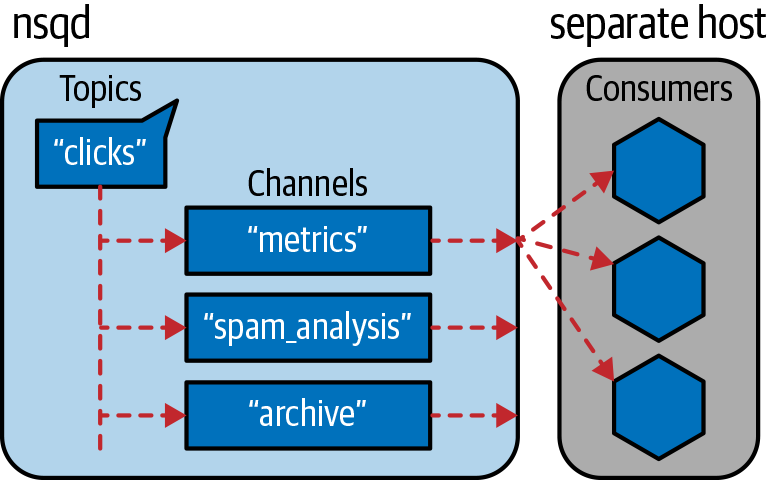

在潜在的大量消费者中传播消息的好处本质上是自动负载平衡。如果一条消息需要相当长的时间来处理，那么在完成之前，该消费者不会向NSQ发出信号，表示它已经准备好接收更多消息，因此其他消费者将获得大多数未来消息（直到原始消费者准备好再次处理）。此外，它允许现有使用者断开连接（无论是选择断开连接还是由于故障断开连接），新使用者连接到集群，同时仍保持特定订阅组中的处理能力。例如，如果我们发现“度量”需要相当长的时间来处理，而且往往跟不上需求，那么我们可以简单地向订阅组的用户池添加更多的进程，从而提高处理能力。另一方面，如果我们看到我们的大多数进程都是空闲的（即，没有得到任何消息），我们可以很容易地从这个订阅池中删除使用者。

还需要注意的是，任何东西都可以发布数据。使用者不仅仅需要是使用者，它可以从一个主题中使用数据，然后将其发布到另一个主题。事实上，对于这种分布式计算的范例来说，这个链是一个重要的工作流。使用者将读取数据主题，以某种方式转换数据，然后将数据发布到其他使用者可以进一步转换的新主题上。这样，不同的主题表示不同的数据，订阅组表示对数据的不同转换，消费者是转换单个消息的实际工作者。

此外，该系统提供了难以置信的冗余。每个使用者可以连接到许多nsqd进程，并且可以有许多使用者连接到特定订阅。这使得它不存在单点故障，即使有几台机器消失，您的系统也将是健壮的。我们可以在图中看到 10-2即使图表中的一台计算机出现故障，系统仍然能够传递和处理消息。另外，由于NSQ在关机时会将挂起的消息保存到磁盘上，除非硬件丢失是灾难性的，否则您的数据很可能仍然完好无损，并且可以被传递。最后，如果某个消费者在响应某个特定消息之前被关闭，NSQ会将该消息重新发送给另一个消费者。这意味着即使消费者被关闭，我们也知道一个主题中的所有消息至少会被响应一次。

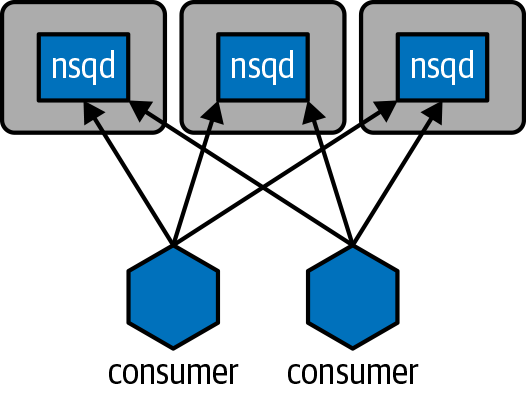

## 分布素数计算

使用NSQ的代码通常是异步的.在下面的示例中，我们将创建一个worker池，从一个名为numbers的主题中读取消息，其中消息只是带有数字的JSON blob。消费者将阅读此主题，找出数字是否为素数，然后根据数字是否为素数写入另一主题。这将给我们两个新的主题，素数和非素数，其他消费者可以连接到，以便做更多的计算。

正如我们之前说过的，这样做有很多好处。首先，我们有健壮性的所有保证，这可能对这个项目有用，也可能不有用。然而，更重要的是，我们得到了自动负载平衡。这意味着，如果一个消费者得到的数字需要花费特别长的时间来处理，那么其他消费者将弥补这个空缺。

我们通过创建一个nsq.Reader对象来创建一个使用者，并指定主题和订阅组（如示例末尾所示） 10-9). 我们还必须指定正在运行的nsqd实例（或nsqlookupd实例）的位置，我们将在本节中不进行讨论。此外，我们还指定了一个处理程序，它只是一个为主题中的每条消息调用的函数。为了创建生产者，我们创建一个nsq.Writer对象并指定一个或多个要写入的nsqd实例的位置。这使我们能够通过指定主题名和消息来写入nsq

例10-9。基于NSQ的分布式素数计算

In [ ]:
import json
from functools import partial
from math import sqrt

import nsq

def is_prime(number):
    if number % 2 == 0:
        return False
    for i in range(3, int(sqrt(number)) + 1, 2):
        if number % i == 0:
            return False
    return True

def write_message(topic, data, writer):
    response = writer.pub(topic, data)
    if isinstance(response, nsq.Error):
        print("Error with Message: {}: {}".format(data, response))
        return write_message(data, writer)
    else:
        print("Published Message: ", data)

def calculate_prime(message, writer):
    data = json.loads(message.body)

    prime = is_prime(data["number"])
    data["prime"] = prime
    if prime:
        topic = "prime"
    else:
        topic = "non_prime"

    output_message = json.dumps(data).encode("utf8")
    write_message(topic, output_message, writer)
    message.finish() #当我们处理完一个消息后，我们必须向NSQ发信号。这将确保在出现故障时不会将消息重新传递给其他读取器。 

if __name__ == "__main__":
    writer = nsq.Writer(["127.0.0.1:4150"])
    handler = partial(calculate_prime, writer=writer)
    reader = nsq.Reader(
        message_handler=handler,
        nsqd_tcp_addresses=["127.0.0.1:4150"],
        topic="numbers",
        channel="worker_group_a",
    )
    nsq.run()

要设置NSQ生态系统，请在本地计算机上启动一个nsqd实例：

现在我们可以开始我们的Python代码的任意多个实例（例如 10-9）我们想要的。事实上，只要nsq.Reader实例化中对 nsqd_tcp_address 的引用仍然有效，我们就可以在其他计算机上运行这些实例。这些使用者将连接到nsqd并等待在数字主题上发布消息。

数据可以以多种方式发布到数字主题。我们将使用命令行工具来实现这一点，因为了解如何戳和戳系统对于理解如何正确处理它有很大的帮助。我们可以简单地使用HTTP接口将消息发布到主题：

当这个命令开始运行时，我们会将带有不同数字的消息发布到数字主题。同时，我们的所有生产者将开始输出状态消息，表明他们已经看到并处理了消息。此外，这些数字被发布到素数或非素数主题。这允许我们有其他数据使用者连接到这些主题中的任何一个，以获得原始数据的过滤子集。例如，一个只需要素数的应用程序可以简单地连接到素数主题，并不断有新的素数进行计算。我们可以使用nsqd的stats HTTP端点查看计算的状态：

我们可以在这里看到，numbers主题有一个订阅组 worker_group_a 和一个consumer。另外，订阅组有1926条消息的深度，这意味着我们将消息放入NSQ的速度比处理它们的速度要快。这将是一个增加更多消费者的迹象，以便我们有更多的处理能力，通过更多的消息。此外，我们可以看到，这个特定的消费者已经连接了15秒，处理了1083条消息，目前有1条消息正在传输中。此状态端点为调试NSQ设置提供了大量信息！最后，我们看到了prime和non_prime主题，它们没有订阅者或使用者。这意味着消息将被存储，直到订户来请求数据。

要真正看到这些消息，我们将为prime（或non_prime）主题创建一个新的使用者，该使用者只需将结果归档到文件或数据库中。或者，我们可以使用nsq_tail 工具查看数据，看看它包含什么：

# 其他集群工具

使用队列的作业处理系统从计算机科学行业开始就存在了，那时计算机非常慢，需要处理大量的作业。因此，有许多用于队列的库，其中许多库可以在集群配置中使用。我们强烈建议您选择一个成熟的库，它背后有一个活跃的社区，并支持相同的功能集，您将需要没有太多额外的功能。

一个库的特性越多，你就会发现错误配置它和在调试上浪费时间的方法就越多。在处理集群解决方案时，简单性通常是正确的目标。以下是一些更常用的群集解决方案：

- ZeroMQ是一个低级别、高性能的消息传递库，它使您能够在节点之间发送消息。它本机支持pub/sub范式，还可以通过多种传输类型（TCP、UDP、WebSocket等）进行通信。它的级别很低，并且没有提供很多有用的抽象，这使得它的使用有点困难。也就是说，它在Jupyter、Auth0、Spotify等许多地方都有使用！

- Celery（BSD许可证）是一种广泛使用的异步任务队列，使用的是用Python编写的分布式消息传递体系结构。它支持Python、PyPy和Jython。它通常使用RabbitMQ作为消息代理，但也支持Redis、MongoDB和其他存储系统。它通常用于web开发项目中。Andrew Godwin在“Lanyrd.com上的任务队列（2014）”中讨论芹菜。

- Airflow和Luigi使用有向无环图将依赖的作业链接到序列中，这些序列通过监视和报告服务可靠地运行。它们在数据科学任务的行业中被广泛使用，我们建议您在开始定制解决方案之前检查这些。

- Amazon的简单队列服务（SQS）是一个集成到AWS中的作业处理系统。工作消费者和生产者可以住在AWS内部，也可以是外部的，因此SQS很容易启动，并支持轻松迁移到云中。许多语言都有库支持。

# Docker

Docker是Python生态系统中一个非常重要的工具。然而，它解决的问题在处理大型团队或集群时尤为重要。特别是，Docker有助于创建可复制的环境，在其中运行代码、共享/控制运行时环境、在团队成员之间轻松共享可运行代码，以及根据资源需求将代码部署到节点集群。

## Docker的性能

关于Docker的一个常见误解是，Docker大大降低了它正在运行的应用程序的运行时性能。虽然这在某些情况下是正确的，但通常不是。此外，大多数性能下降几乎都可以通过一些简单的配置更改来消除。

在CPU和内存访问方面，Docker（以及所有其他基于容器的解决方案）不会导致任何性能下降。这是因为Docker只是在主机操作系统中创建了一个特殊的名称空间，在这个名称空间中代码可以正常运行，尽管有与其他运行程序不同的约束。从本质上讲，Docker代码访问CPU和内存的方式与计算机上的其他程序相同；但是，它可以有一组单独的配置值来微调资源限制

这是因为Docker是操作系统级虚拟化的一个实例，而不是像VMware或VirtualBox这样的硬件虚拟化。通过硬件虚拟化，软件运行在“假”硬件上，这会导致访问所有资源的开销。另一方面，操作系统虚拟化使用本机硬件，但运行在“伪”操作系统上。由于cgroups Linux的特性，这个“假”操作系统可以与正在运行的操作系统紧密耦合，这使得运行几乎没有开销。

作为一个示例，让我们创建一个简单的Docker容器来运行示例中的2D扩散代码 6-17. 作为基准，我们可以在主机系统的Python上运行代码以获得基准：

要创建Docker容器，我们必须创建一个包含Python文件diffusion_numpy_memory2.py、依赖项的pip需求文件和Dockerfile的目录，如示例所示 10-10.

例10-10。简单Docker容器

现在我们已经准备好构建和运行容器，它可以被命名和标记。容器名称通常采用<username>/<project name>格式，而可选标记通常是描述当前代码版本的，或者只是最新的标记（这是默认值，如果没有指定标记，则会自动应用）。为了帮助进行版本控制，通常使用最新版本（在创建新版本时将被覆盖）以及描述性标记来标记最新版本，以便我们将来可以很容易地再次找到此版本：

我们可以看到，Docker的核心是，当任务主要依赖于CPU/内存时，它并不比在主机上以任何有意义的方式运行慢。然而，和任何事情一样，没有免费的午餐，Docker的表现有时会受到影响。虽然优化Docker容器的完整讨论超出了本书的范围，但我们提供了以下为高性能代码创建Docker容器时的注意事项列表：

- 小心将太多数据复制到Docker容器中，甚至在Docker构建的同一目录中有太多数据。如果docker build命令的第一行所公布的构建上下文太大，则性能可能会受到影响（使用.dockrignore文件进行补救）。

- Docker使用各种文件系统技巧将文件系统分层。这有助于缓存生成，但可能比处理主机文件系统慢。当需要快速访问数据时，请使用主机级装载，并考虑使用设置为只读的卷来选择适合您的基础结构的卷驱动程序。

- Docker为您的所有容器创建了一个虚拟网络。这对于将大部分服务隐藏在网关后面非常有用，但也会增加少量的网络开销。对于大多数用例，这种开销可以忽略不计，但是可以通过更改网络驱动程序来减轻。

- GPU和其他主机级设备可以使用Docker的特殊运行时驱动程序进行访问。例如，nvidia docker允许docker环境轻松使用连接的nvidia GPU。通常，可以使用--device runtime标志使设备可用。

像往常一样，重要的是要对Docker容器进行分析，以了解问题是什么，以及在效率方面是否有一些简单的优势。docker stats命令提供了一个良好的高级视图，有助于了解容器的当前运行时性能。

# Docker的优势

到目前为止，Docker似乎只是简单地增加了一系列新的性能问题。然而，运行时环境的可再现性和可靠性远远超过任何额外的复杂性。

在本地，通过访问所有以前运行的Docker容器，我们可以快速地重新运行和重新测试以前版本的代码，而不必担心运行时环境的变化，例如依赖项和系统包（例如 10-11显示了一个容器列表，我们可以用一个简单的docker（run命令）运行。这使得不断测试性能回归变得异常容易，否则很难重现。

例10-11。Docker标记以跟踪以前的运行时环境

使用容器注册表还有很多好处，它允许使用简单的Docker pull和Docker push命令存储和共享Docker图像，方式与git类似。这使我们能够将所有容器放在一个公共可用的位置，允许团队成员引入更改或新版本，并让他们立即运行代码。

运行 docker pull highperformance/diffusion2d:lates 要比克隆存储库和执行运行项目所需的所有相关设置容易得多。对于研究代码尤其如此，因为它们可能具有一些非常脆弱的系统依赖关系。将所有这些放在一个容易拉取的Docker容器中意味着可以跳过所有这些设置步骤，代码也可以很容易地运行。因此，代码可以更容易地共享，编码团队可以更有效地协同工作。

最后，结合kubernetes和其他类似的技术，对代码进行docking有助于实际使用所需的资源运行代码。Kubernetes允许您创建一个节点集群，每个节点都标记有它可能拥有的资源，并协调节点上正在运行的容器。它将负责确保运行的实例数量正确，多亏了Docker虚拟化，代码将在保存到的相同环境中运行。使用集群最大的困难之一是确保集群节点具有正确的运行时环境作为您的工作站，而使用Docker虚拟化完全解决了这一问题

# 小结

到目前为止，在本课程中，我们已经研究了分析以了解代码的缓慢部分、编译和使用numpy使代码运行更快，以及多种方法来处理多个进程和计算机。此外，我们调查了容器虚拟化来管理代码环境和帮助集群部署。在接下来一节中，我们将通过不同的数据结构和概率方法来研究使用较少RAM的方法。这些课程可以帮助您将所有数据保存在一台计算机上，避免运行集群。